# Optional Specific Task 2.2 Train/Evaluate advanced model

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

## Reading Data

In [44]:
def read_txt(path):
    rows = []
    with open(path, "r", encoding="utf-8") as fh:
        lines = fh.read().splitlines()
    for line in lines:
        parts = line.split(": ")
        if len(parts) < 4:
            continue
        rows.append({
            "Event Type": parts[0].strip(),
            "Interaction": parts[1].strip(),
            "Feynman Diagram": parts[2].strip(),
            "Amplitude": parts[-2].strip(),
            "Squared Amplitude": parts[-1].strip()
        })
    return rows

In [45]:
base_dir = "/kaggle/input/datasets/arnavtripathi1/symba-test-data"

qed_data = []
qcd_data = []

for file in os.listdir(base_dir):
    path = os.path.join(base_dir, file)
    rows = read_txt(path)
    if "QED" in file:
        qed_data.extend(rows)
    if "QCD" in file:
        qcd_data.extend(rows)

In [46]:
qed_df = pd.DataFrame(qed_data)
qcd_df = pd.DataFrame(qcd_data)

print("QED dataset size:", len(qed_df))
print("QCD dataset size:", len(qcd_df))

QED dataset size: 360
QCD dataset size: 234


## Train-Val-Test Split

In [47]:
from sklearn.model_selection import train_test_split

# split QED
qed_train, temp_df = train_test_split(qed_df, test_size=0.2, random_state=42, shuffle=True)
qed_val, qed_test = train_test_split(temp_df, test_size=0.5, random_state=42, shuffle=True)

# split QCD
qcd_train, temp_df = train_test_split(qcd_df, test_size=0.2, random_state=42, shuffle=True)
qcd_val, qcd_test = train_test_split(temp_df, test_size=0.5, random_state=42, shuffle=True)

print(f"QED -> Train size : {len(qed_train)}, Validation size : {len(qed_val)}, Test size : {len(qed_test)}")
print(f"QCD -> Train size : {len(qcd_train)}, Validation size : {len(qcd_val)}, Test size : {len(qcd_test)}")

qed_train.to_csv("qed_train.csv")
qed_val.to_csv("qed_val.csv")
qed_test.to_csv("qed_test.csv")

qcd_train.to_csv("qcd_train.csv")
qcd_val.to_csv("qcd_val.csv")
qcd_test.to_csv("qcd_test.csv")

QED -> Train size : 288, Validation size : 36, Test size : 36
QCD -> Train size : 187, Validation size : 23, Test size : 24


## Tokenizer

In [48]:
import json
import unicodedata
import warnings
from typing import List, Tuple, Dict, Any
from tqdm.auto import tqdm
import re
from collections import OrderedDict

class PittTokenizer:
    """Physics-informed tokenizer for amplitudes and squared amplitudes expressions."""
    def __init__(
        self,
        index_token_pool_size = 120,
        momentum_token_pool_size = 10,
        particle_index_pool_size = 10,
        special_symbols = None,
        unk_idx = 3
    ):
        self.index_pool_size = int(index_token_pool_size)
        self.momentum_pool_size = int(momentum_token_pool_size)
        self.particle_index_pool_size = int(particle_index_pool_size)
        self.index_tokens = [f"INDEX_{i}" for i in range(self.index_pool_size)]
        self.momentum_tokens = [f"MOMENTUM_{i}" for i in range(self.momentum_pool_size)]
        self.pindex_tokens = [f"PINDEX_{i}" for i in range(self.particle_index_pool_size)]
        self.special_symbols = special_symbols or ["<BOS>", "<PAD>", "<EOS>", "<UNK>", "<SEP>"]
        self.unk_idx = unk_idx

        # regex patterns
        self._re_whitespace = re.compile(r"\s+")
        self._re_unicode_norm = unicodedata.normalize
        self._re_gamma_token = re.compile(r'gamma_\{([^}]+)\}')
        self._re_wavefunction = re.compile(r'\b([A-Za-z]+)_\{([^}]+)\}\(([^)]+)\)(_[A-Za-z]+)(\^CONJ)?')
        self._re_momentum = re.compile(r'\bp_(\d+)\b')
        self._re_mandelstam = re.compile(r'\bs_(\d+)\b')
        self._re_mass = re.compile(r'\bm_[A-Za-z]+\b')
        self._re_particle_index = re.compile(r'\b([ijkl])_(\d+)\b')
        # candidate indices excluding mass/momentum/mandelstam/particle indices
        self._re_index_candidate = re.compile(r'(?!p_)(?!s_)(?!m_)(?![ijkl]_)[A-Za-z%\\]+_\d+')
        # operators and separators
        self._operators = list('/+-*^,{}()[]:=') 

    # ---- Normalization Utilities ----
    def normalize_unicode_and_whitespace(self, expression):
        """Apply unicode normalization and collapse whitespace."""
        if expression is None:
            return ""
        expr = self._re_unicode_norm("NFKC", expression)
        expr = self._re_whitespace.sub(" ", expr).strip()
        return expr

    def fix_brace_spaces(self, expr):
        """Canonicalize spacing inside {...} blocks:"""
        def clean(match):
            inner = match.group(1)
            inner = inner.strip()
            inner = re.sub(r'\s*,\s*', ',', inner)
            inner = re.sub(r'\s*\+\s*', '+', inner)
            inner = re.sub(r'\s*-\s*', '-', inner)
            return '{' + inner + '}'
        return re.sub(r'\{([^}]*)\}', clean, expr)

    def preprocess_expression(self, expression):
        """Canonicalize common physics tokens and simple formatting."""
        expr = self.normalize_unicode_and_whitespace(str(expression))
        expr = expr.replace("me", "m_e")
        expr = expr.replace("reg_prop", "REG_PROP")
        expr = expr.replace("(*)", "CONJ")
        expr = expr.replace("+-", "-").replace("-+", "-")
        expr = re.sub(r'\s*\*\s*', '*', expr)
        expr = re.sub(r'\s*/\s*', '/', expr)
        expr = re.sub(r'\s*\^\s*', '^', expr)
        expr = re.sub(r'\s*\+\s*', ' + ', expr)
        expr = re.sub(r'\s*-\s*', ' - ', expr)
        expr = re.sub(r'\s+', ' ', expr).strip()
        expr = self.fix_brace_spaces(expr)
        return expr

    def physics_aware_replace(self, expr):
        """Canonicalize momentum, mandelstam, masses, conjugation, imaginary unit and constants."""
        e = expr
        e = self._re_mandelstam.sub(r"MANDELSTAM_\1", e)
        e = self._re_momentum.sub(r"P_\1", e)
        e = self._re_mass.sub(lambda m: m.group(0), e)
        e = re.sub(r'\bi\b(?!\w)', 'I_UNIT', e)
        e = re.sub(r'\be\b(?=\^|[+\-*/()| ,])', 'E_CHARGE', e)
        e = re.sub(r'\bg\b(?=\^|[+\-*/()| ,])', 'G_COUPLING', e)
        return e

    # ---- Index Normalisation and Mapping ----
    def extract_pair_index_order(self, amp, sqamp):
        """Return ordered unique candidate indices, particle indices and momentum matches for a pair."""
        combined = amp + " || " + sqamp
        # find regular index candidates
        seen = OrderedDict()
        for m in self._re_index_candidate.finditer(combined):
            key = m.group(0)
            if key not in seen:
                seen[key] = None
        index_candidates = list(seen.keys())
        # particle indices
        pseen = OrderedDict()
        for m in self._re_particle_index.finditer(combined):
            key = m.group(0)
            if key not in pseen:
                pseen[key] = None
        particle_candidates = list(pseen.keys())
        # momentum occurrences
        mseen = OrderedDict()
        for m in self._re_momentum.finditer(combined):
            key = m.group(0)
            if key not in mseen:
                mseen[key] = None
        momentum_candidates = list(mseen.keys())

        return index_candidates, particle_candidates, momentum_candidates

    def build_deterministic_mapping(self, index_candidates, particle_candidates, momentum_candidates):
        """Create deterministic mapping to INDEX_/PINDEX_/MOMENTUM_ tokens."""
        mapping = {}
        for i, old in enumerate(index_candidates):
            if i >= self.index_pool_size:
                raise RuntimeError("index_pool exhausted; increase index_token_pool_size")
            mapping[old] = self.index_tokens[i]
        for i, old in enumerate(particle_candidates):
            if i >= self.particle_index_pool_size:
                raise RuntimeError("particle_index_pool exhausted; increase particle_index_pool_size")
            mapping[old] = self.pindex_tokens[i]
        for i, old in enumerate(momentum_candidates):
            if i >= self.momentum_pool_size:
                raise RuntimeError("momentum_pool exhausted; increase momentum_token_pool_size")
            mapping[old] = self.momentum_tokens[i]
        return mapping

    def apply_mapping_to_text(self, text, mapping):
        """Replace all full-token matches in text using provided mapping."""
        if not mapping:
            return text
        for old in sorted(mapping.keys(), key=len, reverse=True):
            new = mapping[old]
            text = text.replace(old, new)
        return text

    def normalize_pair_indices(self, ampl, sqamp):
        """Pre-processes and returns strictly mapped strings."""
        amp_p = self.preprocess_expression(ampl)
        sqamp_p = self.preprocess_expression(sqamp)
        idx_cands, p_cands, m_cands = self.extract_pair_index_order(amp_p, sqamp_p)
        mapping = self.build_deterministic_mapping(idx_cands, p_cands, m_cands)
        amp_mapped = self.apply_mapping_to_text(amp_p, mapping)
        sqamp_mapped = self.apply_mapping_to_text(sqamp_p, mapping)
        amp_final = self.physics_aware_replace(amp_mapped)
        sqamp_final = self.physics_aware_replace(sqamp_mapped)
        amp_final = self.fix_brace_spaces(amp_final)
        sqamp_final = self.fix_brace_spaces(sqamp_final)
        return amp_final, sqamp_final, mapping

    def normalize_dataframe_pairs(self, df, keep_mapping=False):
            """Applies normalization to dataframes."""
            records = []
            for _, row in tqdm(df.iterrows(), total=len(df), desc="Normalizing DataFrame Pairs"):
                ampl = row.get("Amplitude", "")
                sqamp = row.get("Squared Amplitude", "")
                ampl_norm, sqamp_norm, mapping = self.normalize_pair_indices(ampl, sqamp)
                rec = row.to_dict()
                rec["Amplitude_norm"] = ampl_norm
                rec["Squared_Amplitude_norm"] = sqamp_norm
                if keep_mapping:
                    rec["index_mapping"] = json.dumps(mapping)
                records.append(rec)
            return pd.DataFrame.from_records(records)
    
    # ---- Splitting Tokens ----
    def expand_structured_tokens(self, text):
        """Expand structured physics tokens by splitting their index/momentum arguments."""
        def _expand_gamma(m):
            inner = m.group(1)
            parts = [p.strip() for p in inner.split(',')]
            return f"GAMMA_{len(parts)} " + " , ".join(parts)
    
        def _expand_wavefunction(m):
            name  = m.group(1).upper()
            inner = m.group(2)
            mom   = m.group(3)
            vtype = m.group(4)
            conj  = " CONJ" if m.group(5) else ""
            parts = [p.strip() for p in inner.split(',')]
            return f"{name}_{len(parts)} " + " , ".join(parts) + f" {mom} {vtype}{conj}"
    
        text = self._re_wavefunction.sub(_expand_wavefunction, text)
        text = self._re_gamma_token.sub(_expand_gamma, text)
        text = re.sub(r'(MOMENTUM_\d+)_(INDEX_\d+)', r'\1 \2', text)
        return text
        
    def split_tokens(self, text):
        """Split on operators and keep tokens intelligible to transformer."""
        t = text
        for op in self._operators:
            t = t.replace(op, f' {op} ')
        # more frequent fractions kept intact
        top_fracs = ["1/2", "1/16", "1/9", "4/9", "1/448", "16/7", "1/144", "1/3", "1/6", "8/7"]
        for f in top_fracs:
            t = re.sub(rf"\b{f.replace('/', ' / ')}\b", f, t)
        t = re.sub(r'\s+', ' ', t).strip()
        tokens = [tok for tok in t.split(' ') if tok]
        return tokens

    def src_tokenize(self, ampl_norm):
        """Tokenize Source expression."""
        if not ampl_norm: return []
        try:
            expanded_str = self.expand_structured_tokens(str(ampl_norm))
            tokens = self.split_tokens(expanded_str)
            return tokens
        except Exception as e:
            warnings.warn(f"Source tokenization failed for '{ampl_norm}': {e}")
            return [self.special_symbols[self.unk_idx]]

    def tgt_tokenize(self, sqamp_norm):
        """Tokenize Target expression."""
        if not sqamp_norm: return []
        try:
            expanded_str = self.expand_structured_tokens(str(sqamp_norm))
            tokens = self.split_tokens(expanded_str)
            return tokens
        except Exception as e:
            warnings.warn(f"Target tokenization failed for '{sqamp_norm}': {e}")
            return [self.special_symbols[self.unk_idx]]

    # ---- Build Vocabularies ----
    def get_base_vocab(self):
        """Returns a set of index, momentum and pindex tokens."""
        base = set(self.special_symbols)
        base.update(self.index_tokens)
        base.update(self.momentum_tokens)
        base.update(self.pindex_tokens)
        return base

    def build_src_vocab(self, df: pd.DataFrame) -> set:
        """Build Source Vocabulary."""
        src_vocab = self.get_base_vocab()
        for s in tqdm(df["Amplitude_norm"].astype(str), total=len(df), desc="Building src vocab"):
            src_vocab.update(self.src_tokenize(s))
        return src_vocab

    def build_tgt_vocab(self, df: pd.DataFrame) -> set:
        """Build Target Vocabulary."""
        tgt_vocab = self.get_base_vocab()
        for s in tqdm(df["Squared_Amplitude_norm"].astype(str), total=len(df), desc="Building tgt vocab"):
            tgt_vocab.update(self.tgt_tokenize(s))
        return tgt_vocab

    def save_vocab(self, path, src_vocab, tgt_vocab):
        """Save Vocabularies to JSON file."""
        out = {
            "special_symbols": self.special_symbols,
            "src_vocab": sorted(list(src_vocab)),
            "tgt_vocab": sorted(list(tgt_vocab))
        }
        with open(path, "w", encoding="utf-8") as fh:
            json.dump(out, fh, ensure_ascii=False, indent=2)

    def load_vocab(self, path):
        """Load Vocabularies from JSON file."""
        with open(path, "r", encoding="utf-8") as fh:
            return json.load(fh)

In [49]:
class SymbolicVocab:
    """Simple vocab mapping between tokens and indices."""
    def __init__(self, tokens, special_symbols):
        remaining_tokens = sorted(list(set(tokens) - set(special_symbols)))
        self.token_list = special_symbols + remaining_tokens
        self.token_to_idx = {tok: i for i, tok in enumerate(self.token_list)}
        self.idx_to_token = {i: tok for tok, i in self.token_to_idx.items()}
        self.bos_idx = self.token_to_idx.get("<BOS>", 0)
        self.pad_idx = self.token_to_idx.get("<PAD>", 1)
        self.eos_idx = self.token_to_idx.get("<EOS>", 2)
        self.unk_idx = self.token_to_idx.get("<UNK>", 3)
        self.sep_idx = self.token_to_idx.get("<SEP>", 4)
        
    def encode(self, tokens):
        return [self.token_to_idx.get(tok, self.unk_idx) for tok in tokens]

    def decode(self, indices, include_special_tokens = True):
        if include_special_tokens:
            return [self.idx_to_token.get(i, "<UNK>") for i in indices]
        
        specials = {self.pad_idx, self.bos_idx, self.eos_idx, self.sep_idx}
        return [self.idx_to_token.get(i, "<UNK>") for i in indices if i not in specials]

    def __len__(self):
        return len(self.token_list)

In [50]:
tokenizer = PittTokenizer()

# Normalising datasets
print("Processing QED dataset")
qed_train = tokenizer.normalize_dataframe_pairs(qed_train)

print("Processing QCD dataset")
qcd_train = tokenizer.normalize_dataframe_pairs(qcd_train)

Processing QED dataset


Normalizing DataFrame Pairs:   0%|          | 0/288 [00:00<?, ?it/s]

Processing QCD dataset


Normalizing DataFrame Pairs:   0%|          | 0/187 [00:00<?, ?it/s]

In [51]:
# Build QED vocabularies
qed_raw_src_vocab = tokenizer.build_src_vocab(qed_train)
qed_raw_tgt_vocab = tokenizer.build_tgt_vocab(qed_train)

qed_src_vocab = SymbolicVocab(qed_raw_src_vocab, tokenizer.special_symbols)
qed_tgt_vocab = SymbolicVocab(qed_raw_tgt_vocab, tokenizer.special_symbols)

# Build QCD vocabularies
qcd_raw_src_vocab = tokenizer.build_src_vocab(qcd_train)
qcd_raw_tgt_vocab = tokenizer.build_tgt_vocab(qcd_train)

qcd_src_vocab = SymbolicVocab(qcd_raw_src_vocab, tokenizer.special_symbols)
qcd_tgt_vocab = SymbolicVocab(qcd_raw_tgt_vocab, tokenizer.special_symbols)

Building src vocab:   0%|          | 0/288 [00:00<?, ?it/s]

Building tgt vocab:   0%|          | 0/288 [00:00<?, ?it/s]

Building src vocab:   0%|          | 0/187 [00:00<?, ?it/s]

Building tgt vocab:   0%|          | 0/187 [00:00<?, ?it/s]

In [52]:
print("QED:")
print(f"Source Vocab Size: {len(qed_src_vocab)}, Target Vocab Size: {len(qed_tgt_vocab)}")

print("\nQCD")
print(f"Source Vocab Size: {len(qcd_src_vocab)}, Target Vocab Size: {len(qcd_tgt_vocab)}")

QED:
Source Vocab Size: 193, Target Vocab Size: 183

QCD
Source Vocab Size: 190, Target Vocab Size: 211


In [53]:
print("Normalizing Validation sets...")
qed_val_norm = tokenizer.normalize_dataframe_pairs(qed_val)
qcd_val_norm = tokenizer.normalize_dataframe_pairs(qcd_val)

Normalizing Validation sets...


Normalizing DataFrame Pairs:   0%|          | 0/36 [00:00<?, ?it/s]

Normalizing DataFrame Pairs:   0%|          | 0/23 [00:00<?, ?it/s]

## Transformer with KAN&MoE Output Head

In [54]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import math
from functools import partial


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


### SineKAN Layer

In [55]:
class SineKANLayer(nn.Module):
    """KAN with sine based basis functions with learnable amplitudes and frequencies."""
    def __init__(self, in_features, out_features, grid_size=8):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        
        self.amplitudes = nn.Parameter(torch.empty(out_features, in_features, grid_size))
        self.frequencies = nn.Parameter(torch.empty(in_features, grid_size))
        self.bias = nn.Parameter(torch.zeros(out_features))
        
        nn.init.normal_(self.amplitudes, mean=0.0, std=0.4 / (in_features * grid_size))
        nn.init.uniform_(self.frequencies, -1.0, 1.0)
        self.register_buffer("phases", self._compute_phases())

    def _compute_phases(self):
        phases = torch.zeros(self.in_features, self.grid_size)
        _A, _K, _C = 0.97241, 0.98844, 0.99945
        for j in range(self.in_features):
            in_phase = j * math.pi / self.in_features
            for k in range(self.grid_size):
                scale = _A * ((k + 1) ** _K) + _C
                phases[j, k] = in_phase + (k * math.pi / scale)
        return phases

    def forward(self, x):
        x_expanded = x.unsqueeze(-1) 
        sin_basis = torch.sin(x_expanded * self.frequencies + self.phases)
        out = torch.einsum('...ig,oig->...o', sin_basis, self.amplitudes) + self.bias
        return out

In [56]:
class NoisyTopKGating(nn.Module):
    """Calculates routing weights and a load-balancing\
    auxiliary loss for a given batch of tokens."""
    def __init__(self, d_model, num_experts, top_k=2):
        super().__init__()
        self.num_experts = num_experts
        self.top_k = top_k
        self.w_gate = nn.Linear(d_model, num_experts)
        self.w_noise = nn.Linear(d_model, num_experts)
        self.softplus = nn.Softplus()

    def forward(self, x):
        clean_logits = self.w_gate(x)
        if self.training:
            raw_noise_stddev = self.w_noise(x)
            noise_stddev = self.softplus(raw_noise_stddev)
            noise = torch.randn_like(clean_logits) * noise_stddev
            logits = clean_logits + noise
        else:
            logits = clean_logits

        top_logits, top_indices = torch.topk(logits, self.top_k, dim=-1)
        top_k_logits = logits.new_full(logits.shape, float('-inf'))
        top_k_logits.scatter_(-1, top_indices, top_logits)
        routing_weights = F.softmax(top_k_logits, dim=-1)
        
        # Calculate Load Balancing Loss
        routing_probs = F.softmax(logits, dim=-1) 
        mask = F.one_hot(top_indices[:, 0], self.num_experts).float()
        density = mask.mean(dim=0) 
        mean_probs = routing_probs.mean(dim=0) 
        aux_loss = (density * mean_probs).sum() * self.num_experts
        
        return routing_weights, top_indices, aux_loss

class SineKANMoELayer(nn.Module):
    """A mixture-of-experts layer that routes tokens to a set of SineKAN experts."""
    def __init__(self, d_model, num_experts=8, top_k=2, kan_grid_size=8):
        super().__init__()
        self.num_experts = num_experts
        self.top_k = top_k
        self.gating = NoisyTopKGating(d_model, num_experts, top_k)
        self.experts = nn.ModuleList([
            SineKANLayer(d_model, d_model, grid_size=kan_grid_size) 
            for _ in range(num_experts)
        ])

    def forward(self, x):
        batch_size, seq_len, d_model = x.shape
        x_flat = x.view(-1, d_model)

        routing_weights, top_indices, aux_loss = self.gating(x_flat)
        final_output = torch.zeros_like(x_flat)

        for i, expert in enumerate(self.experts):
            expert_mask = (top_indices == i).any(dim=-1)
            if not expert_mask.any(): continue

            expert_output = expert(x_flat[expert_mask]) 
            expert_weights = routing_weights[expert_mask, i].unsqueeze(-1)
            final_output[expert_mask] += expert_output * expert_weights

        return final_output.view(batch_size, seq_len, d_model), aux_loss

In [57]:
def hsiren_activation(x):
    """f(x) = sin(sinh(2x))"""
    return torch.sin(torch.sinh(2.0 * x))

def siren_activation(x):
    """f(x) = sin(w0 * x)"""
    w0 = 1.0
    return torch.sin(w0 * x)

class RotaryPositionalEmbedding(nn.Module):
    def __init__(self, d_model, max_seq_len=2048):
        super().__init__()
        self.d_model = d_model
        
        inv_freq = 1.0 / (500000 ** (torch.arange(0, d_model, 2).float() / d_model))
        self.register_buffer("inv_freq", inv_freq)
        
        t = torch.arange(max_seq_len).type_as(self.inv_freq)
        freqs = torch.einsum("i,j->ij", t, self.inv_freq)
        
        emb = torch.cat((freqs, freqs), dim=-1)
        self.register_buffer("cos_cached", emb.cos()[None, None, :, :]) 
        self.register_buffer("sin_cached", emb.sin()[None, None, :, :])

    def rotate_half(self, x):
        x1 = x[..., : x.shape[-1] // 2]
        x2 = x[..., x.shape[-1] // 2 :]
        return torch.cat((-x2, x1), dim=-1)

    def forward(self, x, offset=0):
        t = x.shape[-2]
        cos = self.cos_cached[:, :, offset : offset + t, :]
        sin = self.sin_cached[:, :, offset : offset + t, :]
        return (x * cos) + (self.rotate_half(x) * sin)

### Transformer with KAN&MoE Head

In [58]:
class MoETransformer(nn.Module):
    """A transformer model utilizing a Mixture-of-Experts head."""
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=256, nhead=8, 
                 num_encoder_layers=3, num_decoder_layers=3, dim_feedforward=512, 
                 dropout=0.1, max_seq_len=1600, num_experts=8, top_k=2, 
                 src_pad_idx=1, tgt_pad_idx=1):
        super().__init__()
        self.d_model = d_model
        self.nhead = nhead
        self.head_dim = d_model // nhead

        self.src_emb = nn.Embedding(src_vocab_size, d_model, padding_idx=src_pad_idx)
        self.tgt_emb = nn.Embedding(tgt_vocab_size, d_model, padding_idx=tgt_pad_idx)

        # RoPE Positional Embeddings
        self.rope = RotaryPositionalEmbedding(self.head_dim, max_seq_len)

        # ENCODER
        encoder_layer = nn.TransformerEncoderLayer(
            d_model, nhead, dim_feedforward, 
            dropout, batch_first=True, norm_first=True
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer, 
            num_layers=num_encoder_layers,
            enable_nested_tensor=False  
        )
        # DECODER
        decoder_layer = nn.TransformerDecoderLayer(
            d_model, nhead, dim_feedforward, 
            dropout, batch_first=True, norm_first=True
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_decoder_layers)

        # Expert initialization 
        self.moe = SineKANMoELayer(d_model, num_experts=num_experts, top_k=top_k)
        self.proj = nn.Linear(d_model, tgt_vocab_size)

    def apply_rope(self, x, offset=0):
        b, t, d = x.shape
        x = x.view(b, t, self.nhead, self.head_dim).transpose(1, 2)
        x = self.rope(x, offset=offset)
        return x.transpose(1, 2).reshape(b, t, d)

    def encode(self, src, src_key_padding_mask=None):
        x = self.src_emb(src) * math.sqrt(self.d_model)
        x = self.apply_rope(x)
        return self.encoder(x, src_key_padding_mask=src_key_padding_mask)

    def decode(self, tgt, memory, tgt_mask=None, tgt_key_padding_mask=None, 
               memory_key_padding_mask=None, offset=0):
        x = self.tgt_emb(tgt) * math.sqrt(self.d_model)
        x = self.apply_rope(x, offset=offset)
        return self.decoder(x, memory, tgt_mask=tgt_mask, 
                            tgt_key_padding_mask=tgt_key_padding_mask, 
                            memory_key_padding_mask=memory_key_padding_mask)

    def forward(self, src, tgt, src_key_padding_mask=None, tgt_key_padding_mask=None, tgt_mask=None):
        # FIXED: Call encode and decode properly instead of bypassing RoPE logic
        memory = self.encode(src, src_key_padding_mask)
        dec_out = self.decode(tgt, memory, tgt_mask=tgt_mask, 
                              tgt_key_padding_mask=tgt_key_padding_mask, 
                              memory_key_padding_mask=src_key_padding_mask)
        
        moe_out, aux_loss = self.moe(dec_out)
        return F.log_softmax(self.proj(moe_out), dim=-1), aux_loss

### Dataset & DataLoader

In [59]:
class AmplitudeDataset(Dataset):
    """
    Converts normalised amplitude / squared-amplitude pairs into
    integer token-id sequences ready for the transformer.
    """
    def __init__(self, df, tokenizer, src_vocab, tgt_vocab,
                 max_src_len=None, max_tgt_len=None):
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.data = []

        for _, row in df.iterrows():
            src_ids = src_vocab.encode(tokenizer.src_tokenize(row["Amplitude_norm"]))
            tgt_ids = tgt_vocab.encode(tokenizer.tgt_tokenize(row["Squared_Amplitude_norm"]))
            if max_src_len: src_ids = src_ids[:max_src_len]
            if max_tgt_len: tgt_ids = tgt_ids[:max_tgt_len]
            self.data.append((src_ids, tgt_ids))

    def __len__(self):  return len(self.data)
    def __getitem__(self, i): return self.data[i]


def build_collate(src_vocab, tgt_vocab):
    """Returns a collate_fn that pads and wraps targets with BOS/EOS."""
    pad_src = src_vocab.pad_idx
    pad_tgt = tgt_vocab.pad_idx
    bos     = tgt_vocab.bos_idx
    eos     = tgt_vocab.eos_idx

    def _collate(batch):
        srcs, tgts = zip(*batch)

        # source padding 
        S = max(len(s) for s in srcs)
        src_t = torch.full((len(srcs), S), pad_src, dtype=torch.long)
        # Float mask initialized to 0.0 (attend)
        src_mask = torch.zeros(len(srcs), S, dtype=torch.float)
        for i, s in enumerate(srcs):
            src_t[i, :len(s)] = torch.tensor(s, dtype=torch.long)
            # Mask out padding with -inf
            src_mask[i, len(s):] = float('-inf')

        # target: prepend BOS, append EOS, pad
        wrapped = [[bos] + list(t) + [eos] for t in tgts]
        T = max(len(t) for t in wrapped)
        tgt_t = torch.full((len(wrapped), T), pad_tgt, dtype=torch.long)
        for i, t in enumerate(wrapped):
            tgt_t[i, :len(t)] = torch.tensor(t, dtype=torch.long)

        return src_t, src_mask, tgt_t

    return _collate

### Training & Evaluation Utilities

In [60]:
def train_epoch(model, loader, optimiser, criterion, device, pad_idx):
    model.train()
    total_loss, total_tok = 0.0, 0

    for src, src_mask, tgt in loader:
        src, src_mask, tgt = src.to(device), src_mask.to(device), tgt.to(device)

        tgt_in  = tgt[:, :-1]  
        tgt_out = tgt[:, 1:]  

        T = tgt_in.size(1)
        
        # Causal Attention Mask 
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(T, device=device)
        
        # Padding Mask
        tgt_pad_bool = (tgt_in == pad_idx)
        tgt_pad_mask = torch.zeros_like(tgt_in, dtype=torch.float)
        tgt_pad_mask = tgt_pad_mask.masked_fill(tgt_pad_bool, float('-inf'))

        # Unpack the two return values
        # Inside train_epoch loop
        log_probs, aux_loss = model(src, tgt_in, src_key_padding_mask=src_mask, tgt_key_padding_mask=tgt_pad_mask, tgt_mask=tgt_mask)
        
        main_loss = criterion(log_probs.reshape(-1, log_probs.size(-1)), tgt_out.reshape(-1))
        # 0.01 for MoE balancing
        loss = main_loss + (0.01 * aux_loss)

        optimiser.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimiser.step()

        n_tok        = (tgt_out != pad_idx).sum().item()
        total_loss  += loss.item() * n_tok
        total_tok   += n_tok

    return total_loss / max(total_tok, 1)

@torch.no_grad()
def evaluate(model, loader, criterion, device, pad_idx):
    """Simplified evaluation focusing only on validation loss."""
    model.eval()
    total_loss, total_tok = 0.0, 0

    for src, src_mask, tgt in loader:
        src, src_mask, tgt = src.to(device), src_mask.to(device), tgt.to(device)
        tgt_in, tgt_out = tgt[:, :-1], tgt[:, 1:]

        T = tgt_in.size(1)
        
        # Causal Attention Mask
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(T, device=device)
        
        # Padding Mask
        tgt_pad_bool = (tgt_in == pad_idx)
        tgt_pad_mask = torch.zeros_like(tgt_in, dtype=torch.float)
        tgt_pad_mask = tgt_pad_mask.masked_fill(tgt_pad_bool, float('-inf'))

        log_probs, aux_loss = model(src, tgt_in,
                                    src_key_padding_mask=src_mask,
                                    tgt_key_padding_mask=tgt_pad_mask,
                                    tgt_mask=tgt_mask)

        # Standard loss for evaluation metric reporting
        loss = criterion(log_probs.reshape(-1, log_probs.size(-1)), tgt_out.reshape(-1))
        n_tok = (tgt_out != pad_idx).sum().item()
        total_loss += loss.item() * n_tok
        total_tok += n_tok

    return total_loss / max(total_tok, 1)


def run_training(model, train_loader, val_loader, optimiser, criterion,
                 device, pad_idx, n_epochs, label="", patience=5):
    """Consolidated training loop with Early Stopping and Best Model Loading."""
    history = {"train_loss": [], "val_loss": []}
    
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_state = None

    for ep in range(1, n_epochs + 1):
        tr_loss = train_epoch(model, train_loader, optimiser, criterion, device, pad_idx)
        val_loss = evaluate(model, val_loader, criterion, device, pad_idx)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            torch.save(best_model_state, f"best_model_{label}.pt")
        else:
            epochs_no_improve += 1

        if ep % 5 == 0 or ep == 1:
            print(f"{label} Epoch {ep:3d}/{n_epochs} | Train Loss {tr_loss:.4f} | Val Loss {val_loss:.4f}")
        
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered for {label} at epoch {ep}")
            break

    if best_model_state:
        model.load_state_dict(best_model_state)
        print(f"Loaded best {label} model (Val Loss: {best_val_loss:.4f})")
        
    return history

In [61]:
@torch.no_grad()
def greedy_decode(model, src, src_mask, max_len, bos, eos, pad):
    model.eval()
    device = src.device
    batch_size = src.size(0)
    
    memory = model.encode(src, src_key_padding_mask=src_mask)
    ys = torch.full((batch_size, 1), bos, dtype=torch.long, device=device)
    
    for i in range(max_len - 1):
        sz = ys.size(1)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(sz, device=device)
        
        out = model.decode(ys, memory, tgt_mask=tgt_mask, memory_key_padding_mask=src_mask)

        moe_out, _ = model.moe(out[:, -1:])
        logits = model.proj(moe_out)
        
        next_word = logits.argmax(dim=-1)
        
        ys = torch.cat([ys, next_word], dim=1)
        if (next_word == eos).all():
            break
            
    return ys

def calculate_metrics(model, loader, device, vocab_tgt, max_len):
    """Separate function for true autoregressive sequence and token accuracy."""
    model.eval()
    total_samples, exact_matches = 0, 0
    total_tokens, correct_tokens = 0, 0
    
    bos, eos, pad = vocab_tgt.bos_idx, vocab_tgt.eos_idx, vocab_tgt.pad_idx

    for src, src_mask, tgt in loader:
        src, src_mask, tgt = src.to(device), src_mask.to(device), tgt.to(device)
        batch_size = src.size(0)
        
        generated_ids = greedy_decode(model, src, src_mask, max_len, bos, eos, pad)
        targets = tgt[:, 1:] 
        
        for i in range(batch_size):
            # Extract list and truncate at the first EOS token
            pred_full = generated_ids[i].tolist()
            if eos in pred_full:
                pred_full = pred_full[:pred_full.index(eos)]
                
            gold_full = targets[i].tolist()
            if eos in gold_full:
                gold_full = gold_full[:gold_full.index(eos)]
            
            # Filter out any BOS/PAD that might exist before EOS
            pred = [t for t in pred_full if t not in [bos, pad]]
            gold = [t for t in gold_full if t not in [bos, pad]]
            
            if pred == gold:
                exact_matches += 1
            
            for j in range(len(gold)):
                total_tokens += 1
                if j < len(pred) and pred[j] == gold[j]:
                    correct_tokens += 1
                    
        total_samples += batch_size

    return exact_matches / total_samples, correct_tokens / total_tokens

### QED Transformer - Training

In [62]:
QED_MAX_SRC = 1024   
QED_MAX_TGT = 1024   
QED_BATCH   = 16
QED_EPOCHS  = 250
QED_D_MODEL = 256
QED_NHEAD   = 4
QED_ENC_DEC = 3      
QED_FFN     = 512
QED_LR      = 1e-4
NUM_EXPERTS = 8
TOP_K       = 2

# Build datasets & loaders
qed_train_ds = AmplitudeDataset(qed_train, tokenizer, qed_src_vocab, qed_tgt_vocab, QED_MAX_SRC, QED_MAX_TGT)
qed_val_ds   = AmplitudeDataset(qed_val_norm, tokenizer, qed_src_vocab, qed_tgt_vocab, QED_MAX_SRC, QED_MAX_TGT)

qed_collate   = build_collate(qed_src_vocab, qed_tgt_vocab)
qed_train_ldr = DataLoader(qed_train_ds, batch_size=QED_BATCH, shuffle=True,  collate_fn=qed_collate)
qed_val_ldr   = DataLoader(qed_val_ds,   batch_size=QED_BATCH, shuffle=False, collate_fn=qed_collate)

In [63]:
# Model
qed_model = MoETransformer(
    src_vocab_size=len(qed_src_vocab),
    tgt_vocab_size=len(qed_tgt_vocab),
    d_model=QED_D_MODEL,
    nhead=QED_NHEAD,
    num_encoder_layers=QED_ENC_DEC,
    num_decoder_layers=QED_ENC_DEC,
    dim_feedforward=QED_FFN,
    dropout=0.1,
    max_seq_len=QED_MAX_SRC, 
    num_experts=NUM_EXPERTS,
    top_k=TOP_K,
    src_pad_idx=qed_src_vocab.pad_idx,
    tgt_pad_idx=qed_tgt_vocab.pad_idx,
).to(device)

n_params_qed = sum(p.numel() for p in qed_model.parameters())
print(f"QED model | parameters: {n_params_qed:,}")
print(f"  src vocab: {len(qed_src_vocab)} | tgt vocab: {len(qed_tgt_vocab)}")

# Optimiser & loss
opt_qed = torch.optim.AdamW(qed_model.parameters(), lr=QED_LR)
loss_qed = nn.CrossEntropyLoss(ignore_index=qed_tgt_vocab.pad_idx)

# Train
print("\n=== Training QED SineKAN-Transformer ===")
qed_history = run_training(qed_model, qed_train_ldr, qed_val_ldr, opt_qed, loss_qed, 
                           device, qed_tgt_vocab.pad_idx, QED_EPOCHS, "QED", patience=20)

QED model | parameters: 8,313,799
  src vocab: 193 | tgt vocab: 183

=== Training QED SineKAN-Transformer ===
QED Epoch   1/250 | Train Loss 4.9599 | Val Loss 4.5602
QED Epoch   5/250 | Train Loss 1.5278 | Val Loss 1.1404
QED Epoch  10/250 | Train Loss 0.4318 | Val Loss 0.2957
QED Epoch  15/250 | Train Loss 0.2259 | Val Loss 0.1508
QED Epoch  20/250 | Train Loss 0.1541 | Val Loss 0.1110
QED Epoch  25/250 | Train Loss 0.1192 | Val Loss 0.0918
QED Epoch  30/250 | Train Loss 0.1036 | Val Loss 0.0756
QED Epoch  35/250 | Train Loss 0.0819 | Val Loss 0.0613
QED Epoch  40/250 | Train Loss 0.0673 | Val Loss 0.0504
QED Epoch  45/250 | Train Loss 0.0551 | Val Loss 0.0398
QED Epoch  50/250 | Train Loss 0.0458 | Val Loss 0.0340
QED Epoch  55/250 | Train Loss 0.0378 | Val Loss 0.0317
QED Epoch  60/250 | Train Loss 0.0328 | Val Loss 0.0285
QED Epoch  65/250 | Train Loss 0.0276 | Val Loss 0.0271
QED Epoch  70/250 | Train Loss 0.0244 | Val Loss 0.0243
QED Epoch  75/250 | Train Loss 0.0223 | Val Loss 0

In [64]:
print("\n=== Evaluating QED Generation ===")
qed_seq_acc, qed_tok_acc = calculate_metrics(qed_model, qed_val_ldr, device, qed_tgt_vocab, max_len=QED_MAX_TGT)
print(f"QED Final Results | Sequence Accuracy: {qed_seq_acc:.4f} | Token Accuracy (Auto-reg): {qed_tok_acc:.4f}")


=== Evaluating QED Generation ===
QED Final Results | Sequence Accuracy: 0.6667 | Token Accuracy (Auto-reg): 0.9918


### QCD Transformer - Training

In [65]:
QCD_MAX_SRC = 2024   
QCD_MAX_TGT = 2024
QCD_BATCH   = 8     
QCD_EPOCHS  = 250
QCD_D_MODEL = 256
QCD_NHEAD   = 4
QCD_ENC_DEC = 3
QCD_FFN     = 512
QCD_LR      = 1e-4
NUM_EXPERTS = 8
TOP_K       = 2

# Datasets & loaders
qcd_train_ds = AmplitudeDataset(qcd_train, tokenizer, qcd_src_vocab, qcd_tgt_vocab, QCD_MAX_SRC, QCD_MAX_TGT)
qcd_val_ds   = AmplitudeDataset(qcd_val_norm, tokenizer, qcd_src_vocab, qcd_tgt_vocab, QCD_MAX_SRC, QCD_MAX_TGT)

qcd_collate   = build_collate(qcd_src_vocab, qcd_tgt_vocab)
qcd_train_ldr = DataLoader(qcd_train_ds, batch_size=QCD_BATCH, shuffle=True,  collate_fn=qcd_collate)
qcd_val_ldr   = DataLoader(qcd_val_ds,   batch_size=QCD_BATCH, shuffle=False, collate_fn=qcd_collate)

In [66]:
# Model
qcd_model = MoETransformer(
    src_vocab_size=len(qcd_src_vocab),
    tgt_vocab_size=len(qcd_tgt_vocab),
    d_model=QCD_D_MODEL,
    nhead=QCD_NHEAD,
    num_encoder_layers=QCD_ENC_DEC,
    num_decoder_layers=QCD_ENC_DEC,
    dim_feedforward=QCD_FFN,
    dropout=0.1,
    max_seq_len=QCD_MAX_SRC, 
    num_experts=NUM_EXPERTS,
    top_k=TOP_K,
    src_pad_idx=qcd_src_vocab.pad_idx,
    tgt_pad_idx=qcd_tgt_vocab.pad_idx,
).to(device)

n_params_qcd = sum(p.numel() for p in qcd_model.parameters())
print(f"QCD model | parameters: {n_params_qcd:,}")
print(f"  src vocab: {len(qcd_src_vocab)} | tgt vocab: {len(qcd_tgt_vocab)}")

# Optimiser & loss
opt_qcd = torch.optim.AdamW(qcd_model.parameters(), lr=QCD_LR)
loss_qcd = nn.CrossEntropyLoss(ignore_index=qcd_tgt_vocab.pad_idx)

# Train
print("\n=== Training QCD SineKAN-Transformer ===")
qcd_history = run_training(qcd_model, qcd_train_ldr, qcd_val_ldr, opt_qcd, loss_qcd, 
                           device, qcd_tgt_vocab.pad_idx, QCD_EPOCHS, "QCD", patience=20)

QCD model | parameters: 8,327,395
  src vocab: 190 | tgt vocab: 211

=== Training QCD SineKAN-Transformer ===
QCD Epoch   1/250 | Train Loss 5.0851 | Val Loss 4.6193
QCD Epoch   5/250 | Train Loss 1.7373 | Val Loss 1.5340
QCD Epoch  10/250 | Train Loss 1.0138 | Val Loss 0.9184
QCD Epoch  15/250 | Train Loss 0.7128 | Val Loss 0.6196
QCD Epoch  20/250 | Train Loss 0.5330 | Val Loss 0.4376
QCD Epoch  25/250 | Train Loss 0.4048 | Val Loss 0.3194
QCD Epoch  30/250 | Train Loss 0.3185 | Val Loss 0.2444
QCD Epoch  35/250 | Train Loss 0.2626 | Val Loss 0.2080
QCD Epoch  40/250 | Train Loss 0.2227 | Val Loss 0.1799
QCD Epoch  45/250 | Train Loss 0.1919 | Val Loss 0.1608
QCD Epoch  50/250 | Train Loss 0.1694 | Val Loss 0.1507
QCD Epoch  55/250 | Train Loss 0.1445 | Val Loss 0.1431
QCD Epoch  60/250 | Train Loss 0.1255 | Val Loss 0.1330
QCD Epoch  65/250 | Train Loss 0.1075 | Val Loss 0.1144
QCD Epoch  70/250 | Train Loss 0.0915 | Val Loss 0.0999
QCD Epoch  75/250 | Train Loss 0.0749 | Val Loss 0

In [67]:
print("\n=== Evaluating QCD Generation ===")
qcd_seq_acc, qcd_tok_acc = calculate_metrics(qcd_model, qcd_val_ldr, device, qcd_tgt_vocab, max_len=QCD_MAX_TGT)
print(f"QCD Final Results | Sequence Accuracy: {qcd_seq_acc:.4f} | Token Accuracy (Auto-reg): {qcd_tok_acc:.4f}")


=== Evaluating QCD Generation ===
QCD Final Results | Sequence Accuracy: 0.6522 | Token Accuracy (Auto-reg): 0.9030


### Training Curves

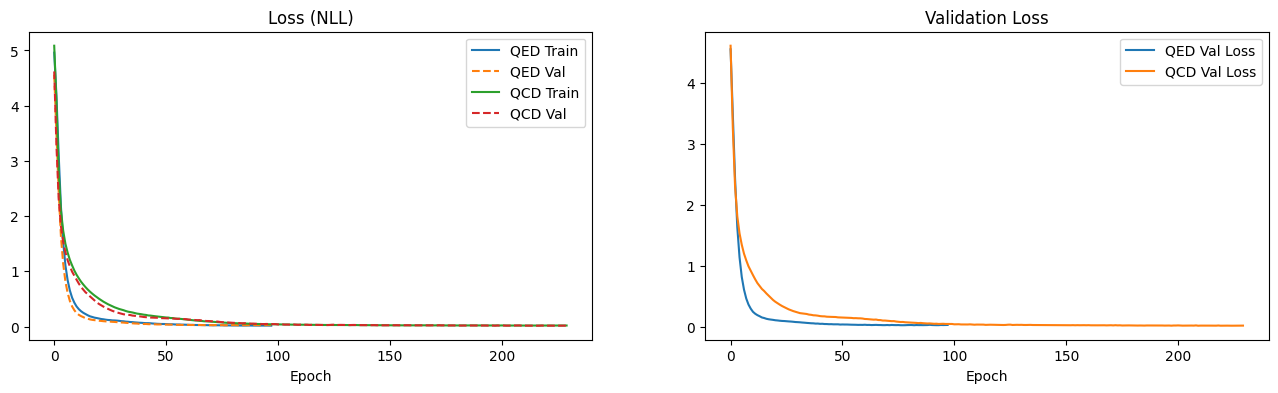

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Loss
axes[0].plot(qed_history["train_loss"], label="QED Train")
axes[0].plot(qed_history["val_loss"],   label="QED Val", linestyle="--")
axes[0].plot(qcd_history["train_loss"], label="QCD Train")
axes[0].plot(qcd_history["val_loss"],   label="QCD Val", linestyle="--")
axes[0].set_title("Loss (NLL)")
axes[0].set_xlabel("Epoch"); axes[0].legend()

# Val Loss
axes[1].plot(qed_history["val_loss"],  label="QED Val Loss")
axes[1].plot(qcd_history["val_loss"],  label="QCD Val Loss")
axes[1].set_title("Validation Loss")
axes[1].set_xlabel("Epoch"); axes[1].legend()

plt.show()